In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_parquet(r"C:\Users\jumma\Downloads\online_retail_cleaned.parquet")
print(f"Rows: {len(df):,}")
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
df.head()

Rows: 1,021,330
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,CustomerType,IsCancellation,Revenue,Year,Month,MonthName,DayOfWeek,Hour,YearMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,Registered,False,83.4,2009,12,December,Tuesday,7,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Registered,False,81.0,2009,12,December,Tuesday,7,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Registered,False,81.0,2009,12,December,Tuesday,7,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,Registered,False,100.8,2009,12,December,Tuesday,7,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,Registered,False,30.0,2009,12,December,Tuesday,7,2009-12


In [2]:
df_reg = df[df['CustomerType'] == 'Registered'].copy()
df_reg = df_reg[df_reg['IsCancellation'] == False]
print(f"Registered transactions: {len(df_reg):,}")
print(f"Unique customers: {df_reg['Customer ID'].nunique():,}")

Registered transactions: 776,577
Unique customers: 5,852


Distribution of days between purchases:
count    770725.000000
mean          2.061068
std          18.216675
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         714.000000
Name: days_since_last, dtype: float64


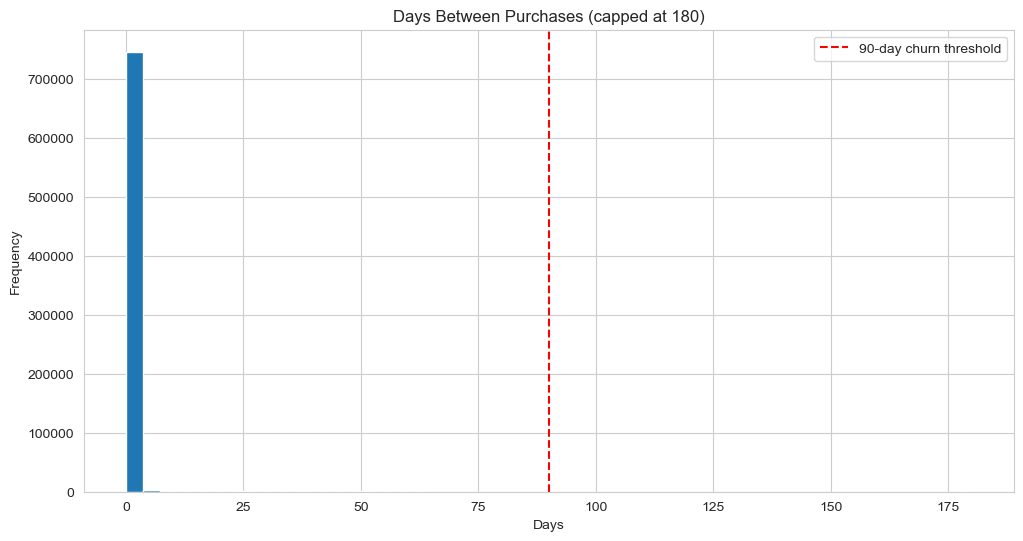

In [3]:
customer_gaps = df_reg.sort_values(['Customer ID', 'InvoiceDate'])
customer_gaps['days_since_last'] = customer_gaps.groupby('Customer ID')['InvoiceDate'].diff().dt.days

print("Distribution of days between purchases:")
print(customer_gaps['days_since_last'].describe())

customer_gaps['days_since_last'].clip(upper=180).hist(bins=50)
plt.title("Days Between Purchases (capped at 180)")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.axvline(90, color='red', linestyle='--', label='90-day churn threshold')
plt.legend()
plt.show()

In [4]:
analysis_date = df_reg['InvoiceDate'].max()
churn_cutoff = analysis_date - pd.Timedelta(days=90)

print(f"Analysis date: {analysis_date}")
print(f"Churn cutoff: {churn_cutoff.date()}")

customer_last_purchase = df_reg.groupby('Customer ID')['InvoiceDate'].max().reset_index()
customer_last_purchase.columns = ['Customer ID', 'last_purchase_date']
customer_last_purchase['churned'] = (customer_last_purchase['last_purchase_date'] < churn_cutoff).astype(int)

print("\nChurn distribution:")
print(customer_last_purchase['churned'].value_counts())
print(f"\nChurn rate: {customer_last_purchase['churned'].mean()*100:.1f}%")

Analysis date: 2011-12-09 12:50:00
Churn cutoff: 2011-09-10

Churn distribution:
churned
1    2967
0    2885
Name: count, dtype: int64

Churn rate: 50.7%


In [5]:
feature_window = df_reg[df_reg['InvoiceDate'] < churn_cutoff].copy()
print(f"Feature window: {feature_window['InvoiceDate'].min()} to {feature_window['InvoiceDate'].max()}")
print(f"Transactions in feature window: {len(feature_window):,}")

features = feature_window.groupby('Customer ID').agg(
    recency_days=('InvoiceDate', lambda x: (churn_cutoff - x.max()).days),
    frequency=('Invoice', 'nunique'),
    monetary=('Revenue', 'sum'),
    avg_order_value=('Revenue', 'mean'),
    total_quantity=('Quantity', 'sum'),
    unique_products=('StockCode', 'nunique'),
    first_purchase=('InvoiceDate', 'min'),
    last_purchase=('InvoiceDate', 'max'),
    country=('Country', 'first')
).reset_index()

features['tenure_days'] = (features['last_purchase'] - features['first_purchase']).dt.days
features['avg_days_between_orders'] = features['tenure_days'] / features['frequency'].clip(lower=1)
features['revenue_per_day'] = features['monetary'] / features['tenure_days'].clip(lower=1)

features = features.drop(['first_purchase', 'last_purchase'], axis=1)

print(f"\nFeatures created for {len(features):,} customers")
features.head()

Feature window: 2009-12-01 07:45:00 to 2011-09-09 15:53:00
Transactions in feature window: 618,314

Features created for 5,256 customers


,Customer ID,recency_days,frequency,monetary,avg_order_value,total_quantity,unique_products,country,tenure_days,avg_days_between_orders,revenue_per_day
0,12346,235,3,77352.96,3094.118400,74239,25,United Kingdom,321,107.000000,240.974953
1,12347,39,6,3402.39,20.746280,2099,107,Iceland,274,45.666667,12.417482
2,12348,158,4,1388.40,31.554545,2488,24,Finland,189,47.250000,7.346032
3,12349,317,2,2221.14,22.211400,991,89,Italy,181,90.500000,12.271492
4,12350,219,1,294.40,18.400000,196,16,Norway,0,0.000000,294.400000


In [6]:
ml_data = features.merge(
    customer_last_purchase[['Customer ID', 'churned']], 
    on='Customer ID',
    how='inner'
)

print(f"Final ML dataset shape: {ml_data.shape}")
print(f"Churn rate: {ml_data['churned'].mean()*100:.1f}%")

# Save as parquet for fast reload
ml_data.to_parquet(r"C:\Users\jumma\Downloads\churn_features.parquet")
print("\n✓ Features saved as Parquet")

ml_data.head()

Final ML dataset shape: (5256, 12)
Churn rate: 56.4%

✓ Features saved as Parquet


,Customer ID,recency_days,frequency,monetary,avg_order_value,total_quantity,unique_products,country,tenure_days,avg_days_between_orders,revenue_per_day,churned
0,12346,235,3,77352.96,3094.118400,74239,25,United Kingdom,321,107.000000,240.974953,1
1,12347,39,6,3402.39,20.746280,2099,107,Iceland,274,45.666667,12.417482,0
2,12348,158,4,1388.40,31.554545,2488,24,Finland,189,47.250000,7.346032,0
3,12349,317,2,2221.14,22.211400,991,89,Italy,181,90.500000,12.271492,0
4,12350,219,1,294.40,18.400000,196,16,Norway,0,0.000000,294.400000,1


In [7]:
# Reload from Parquet (fast)
ml_data = pd.read_parquet(r"C:\Users\jumma\Downloads\churn_features.parquet")
print(f"Loaded: {ml_data.shape}")

# Handle single-purchase customers (tenure = 0)
# Replace with 1 day to avoid divide-by-zero issues
ml_data['tenure_days'] = ml_data['tenure_days'].replace(0, 1)
ml_data['avg_days_between_orders'] = ml_data['monetary'] / ml_data['frequency'].clip(lower=1)

# Quick sanity check
print(ml_data.describe())

Loaded: (5256, 12)
        Customer ID  recency_days    frequency       monetary  \
count   5256.000000   5256.000000  5256.000000    5256.000000   
mean   15329.515221    206.357496     5.711377    2604.799266   
std     1711.753811    174.352314    11.213991   12095.387818   
min    12346.000000      0.000000     1.000000       1.550000   
25%    13855.750000     49.000000     1.000000     316.610000   
50%    15321.500000    163.000000     3.000000     776.560000   
75%    16813.250000    324.000000     6.000000    2061.877500   
max    18287.000000    648.000000   284.000000  456780.490000   

       avg_order_value  total_quantity  unique_products  tenure_days  \
count      5256.000000     5256.000000      5256.000000  5256.000000   
mean         34.145366     1627.593417        74.553843   224.742199   
std         211.479141     8063.653044       104.971863   218.277088   
min           1.450000        1.000000         1.000000     1.000000   
25%          11.484040      170.000

In [8]:
# Drop columns we don't want as features
# - Customer ID: just a label, not a feature
# - country: categorical, we'll handle separately
# - churned: this is our target!

# Encode country as a feature (top countries vs "Other")
top_countries = ml_data['country'].value_counts().head(5).index.tolist()
ml_data['country_grouped'] = ml_data['country'].where(
    ml_data['country'].isin(top_countries), 
    'Other'
)
print("Top countries used as features:")
print(ml_data['country_grouped'].value_counts())

# One-hot encode country
ml_data_encoded = pd.get_dummies(ml_data, columns=['country_grouped'], prefix='country')

# Drop columns not used in model
X = ml_data_encoded.drop(['Customer ID', 'country', 'churned'], axis=1)
y = ml_data_encoded['churned']

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns:")
print(X.columns.tolist())

Top countries used as features:
country_grouped
United Kingdom    4799
Other              233
Germany             93
France              74
Spain               31
Belgium             26
Name: count, dtype: int64

Features shape: (5256, 15)
Target shape: (5256,)

Feature columns:
['recency_days', 'frequency', 'monetary', 'avg_order_value', 'total_quantity', 'unique_products', 'tenure_days', 'avg_days_between_orders', 'revenue_per_day', 'country_Belgium', 'country_France', 'country_Germany', 'country_Other', 'country_Spain', 'country_United Kingdom']


In [9]:
from sklearn.model_selection import train_test_split

# 80/20 split with stratification (preserves churn ratio in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]:,} customers")
print(f"Test set: {X_test.shape[0]:,} customers")
print(f"\nChurn rate in training: {y_train.mean()*100:.1f}%")
print(f"Churn rate in test: {y_test.mean()*100:.1f}%")

Training set: 4,204 customers
Test set: 1,052 customers

Churn rate in training: 56.4%
Churn rate in test: 56.5%


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled (mean=0, std=1)")

✓ Features scaled (mean=0, std=1)


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

print("=== LOGISTIC REGRESSION ===")
print(f"ROC-AUC: {roc_auc_score(y_test, lr_probs):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, lr_preds, target_names=['Active', 'Churned']))

=== LOGISTIC REGRESSION ===
ROC-AUC: 0.7876

Classification Report:
              precision    recall  f1-score   support

      Active       0.69      0.66      0.68       458
     Churned       0.75      0.77      0.76       594

    accuracy                           0.72      1052
   macro avg       0.72      0.72      0.72      1052
weighted avg       0.72      0.72      0.72      1052



In [12]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1   # use all CPU cores
)
rf_model.fit(X_train, y_train)  # Random Forest doesn't need scaling

rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print("=== RANDOM FOREST ===")
print(f"ROC-AUC: {roc_auc_score(y_test, rf_probs):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, rf_preds, target_names=['Active', 'Churned']))

=== RANDOM FOREST ===
ROC-AUC: 0.7907

Classification Report:
              precision    recall  f1-score   support

      Active       0.70      0.63      0.67       458
     Churned       0.74      0.79      0.76       594

    accuracy                           0.72      1052
   macro avg       0.72      0.71      0.71      1052
weighted avg       0.72      0.72      0.72      1052



In [13]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBOOST ===")
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_probs):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, xgb_preds, target_names=['Active', 'Churned']))

=== XGBOOST ===
ROC-AUC: 0.7801

Classification Report:
              precision    recall  f1-score   support

      Active       0.69      0.62      0.66       458
     Churned       0.73      0.79      0.76       594

    accuracy                           0.72      1052
   macro avg       0.71      0.71      0.71      1052
weighted avg       0.72      0.72      0.71      1052



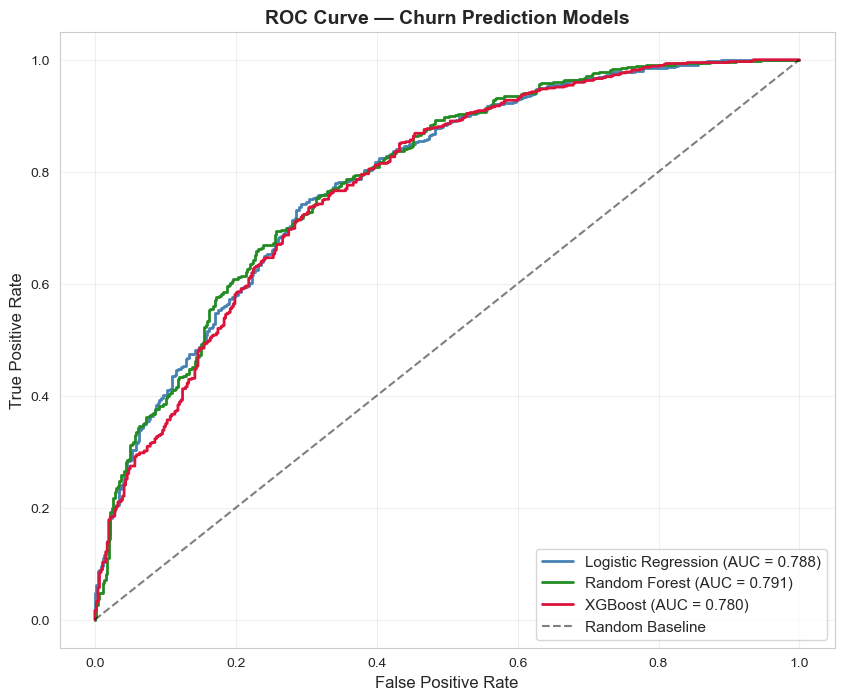

In [14]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 8))

for name, probs, color in [
    ('Logistic Regression', lr_probs, 'steelblue'),
    ('Random Forest', rf_probs, 'forestgreen'),
    ('XGBoost', xgb_probs, 'crimson')
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2, color=color)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Baseline')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Churn Prediction Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

=== XGBoost Feature Importance ===
                    feature  importance
0              recency_days    0.176663
2                  monetary    0.106079
1                 frequency    0.095999
13            country_Spain    0.082090
5           unique_products    0.068660
8           revenue_per_day    0.060721
6               tenure_days    0.058520
7   avg_days_between_orders    0.055109
4            total_quantity    0.053216
11          country_Germany    0.050323
10           country_France    0.049995
3           avg_order_value    0.046769
12            country_Other    0.039641
14   country_United Kingdom    0.034764
9           country_Belgium    0.021451


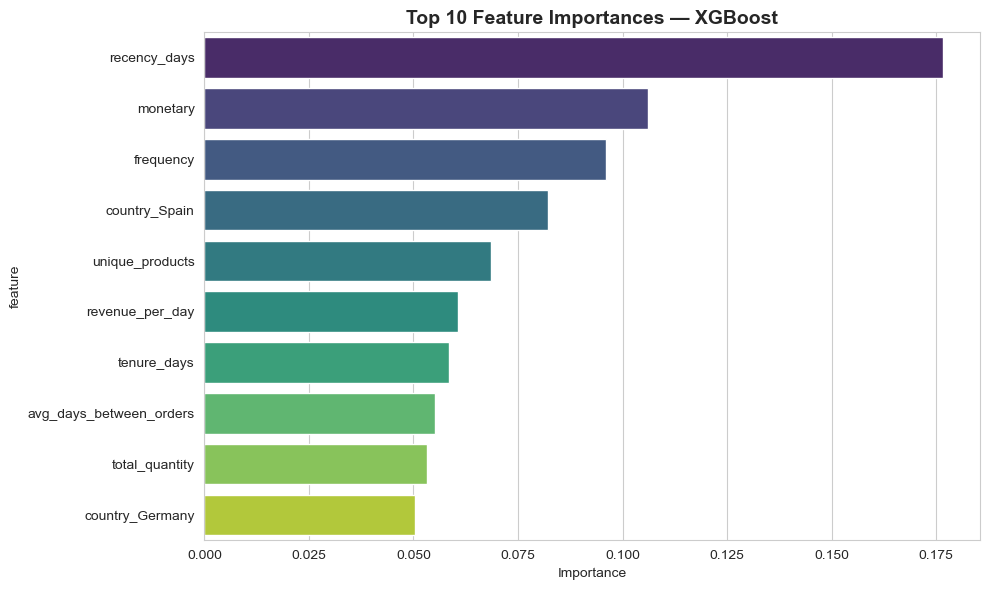

In [17]:
# Feature importance from XGBoost
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("=== XGBoost Feature Importance ===")
print(feature_importance)

# Visualize
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature', palette='viridis')
plt.title('Top 10 Feature Importances — XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

Correlation between recency_days and churn: 0.435


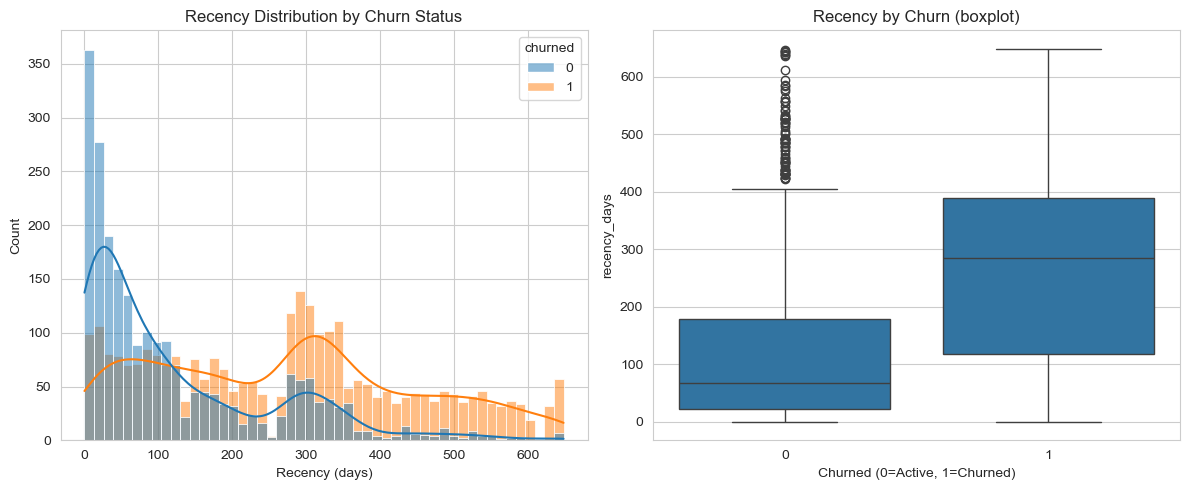

In [16]:
# How predictive is recency alone?
import numpy as np

correlation = ml_data['recency_days'].corr(ml_data['churned'])
print(f"Correlation between recency_days and churn: {correlation:.3f}")

# Distribution of recency by churn status
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=ml_data, x='recency_days', hue='churned', bins=50, kde=True)
plt.title('Recency Distribution by Churn Status')
plt.xlabel('Recency (days)')

plt.subplot(1, 2, 2)
sns.boxplot(data=ml_data, x='churned', y='recency_days')
plt.title('Recency by Churn (boxplot)')
plt.xlabel('Churned (0=Active, 1=Churned)')
plt.tight_layout()
plt.show()

In [19]:
# === ENHANCED FEATURE ENGINEERING ===

# Filter to feature window (before churn cutoff)
feature_window = df_reg[df_reg['InvoiceDate'] < churn_cutoff].copy()

# Define time windows for trend features
recent_cutoff = churn_cutoff - pd.Timedelta(days=60)    # last 60 days before cutoff
older_cutoff = churn_cutoff - pd.Timedelta(days=180)   # 60-180 days before cutoff

# Recent activity (last 60 days)
recent = feature_window[feature_window['InvoiceDate'] >= recent_cutoff].groupby('Customer ID').agg(
    recent_orders=('Invoice', 'nunique'),
    recent_revenue=('Revenue', 'sum'),
    recent_quantity=('Quantity', 'sum')
).reset_index()

# Older activity (60-180 days ago)
older = feature_window[
    (feature_window['InvoiceDate'] >= older_cutoff) & 
    (feature_window['InvoiceDate'] < recent_cutoff)
].groupby('Customer ID').agg(
    older_orders=('Invoice', 'nunique'),
    older_revenue=('Revenue', 'sum')
).reset_index()

# All-time activity
all_time = feature_window.groupby('Customer ID').agg(
    total_orders=('Invoice', 'nunique'),
    total_revenue=('Revenue', 'sum'),
    avg_order_value=('Revenue', 'mean'),
    unique_products=('StockCode', 'nunique'),
    first_purchase=('InvoiceDate', 'min'),
    last_purchase=('InvoiceDate', 'max'),
    country=('Country', 'first')
).reset_index()

# Combine all
features_v2 = all_time.merge(recent, on='Customer ID', how='left')
features_v2 = features_v2.merge(older, on='Customer ID', how='left')

# Fill NaN with 0 (customer had no activity in that period)
features_v2['recent_orders'] = features_v2['recent_orders'].fillna(0)
features_v2['recent_revenue'] = features_v2['recent_revenue'].fillna(0)
features_v2['recent_quantity'] = features_v2['recent_quantity'].fillna(0)
features_v2['older_orders'] = features_v2['older_orders'].fillna(0)
features_v2['older_revenue'] = features_v2['older_revenue'].fillna(0)

# THE KEY FEATURES — trend signals
features_v2['recency_days'] = (churn_cutoff - features_v2['last_purchase']).dt.days
features_v2['tenure_days'] = (features_v2['last_purchase'] - features_v2['first_purchase']).dt.days.clip(lower=1)

# Revenue trend: is recent spend higher or lower than older?
features_v2['revenue_trend'] = (
    features_v2['recent_revenue'] - features_v2['older_revenue']
) / features_v2['older_revenue'].clip(lower=1)

# Order trend: are they ordering more or less recently?
features_v2['order_trend'] = (
    features_v2['recent_orders'] - features_v2['older_orders']
) / features_v2['older_orders'].clip(lower=1)

# Activity ratio: what % of their activity is recent?
features_v2['recent_activity_ratio'] = features_v2['recent_revenue'] / features_v2['total_revenue'].clip(lower=1)

# Average days between orders
features_v2['avg_days_between_orders'] = features_v2['tenure_days'] / features_v2['total_orders'].clip(lower=1)

# Drop helper columns
features_v2 = features_v2.drop(['first_purchase', 'last_purchase'], axis=1)

# Add target
features_v2 = features_v2.merge(
    customer_last_purchase[['Customer ID', 'churned']],
    on='Customer ID'
)

print(f"Enhanced features shape: {features_v2.shape}")
print(f"\nNew features added:")
print("- recent_orders, recent_revenue, recent_quantity (last 60 days)")
print("- older_orders, older_revenue (60-180 days ago)")
print("- revenue_trend (recent vs older — KEY signal)")
print("- order_trend (KEY signal)")
print("- recent_activity_ratio")

features_v2.head()

Enhanced features shape: (5256, 18)

New features added:
- recent_orders, recent_revenue, recent_quantity (last 60 days)
- older_orders, older_revenue (60-180 days ago)
- revenue_trend (recent vs older — KEY signal)
- order_trend (KEY signal)
- recent_activity_ratio


,Customer ID,total_orders,total_revenue,avg_order_value,unique_products,country,recent_orders,recent_revenue,recent_quantity,older_orders,older_revenue,recency_days,tenure_days,revenue_trend,order_trend,recent_activity_ratio,avg_days_between_orders,churned
0,12346,3,77352.96,3094.118400,25,United Kingdom,0.0,0.00,0.0,0.0,0.00,235,321,0.000000,0.0,0.000000,107.000000,1
1,12347,6,3402.39,20.746280,107,Iceland,1.0,584.91,277.0,2.0,1018.77,39,274,-0.425866,-0.5,0.171912,45.666667,0
2,12348,4,1388.40,31.554545,24,Finland,0.0,0.00,0.0,1.0,327.00,158,189,-1.000000,-1.0,0.000000,47.250000,0
3,12349,2,2221.14,22.211400,89,Italy,0.0,0.00,0.0,0.0,0.00,317,181,0.000000,0.0,0.000000,90.500000,0
4,12350,1,294.40,18.400000,16,Norway,0.0,0.00,0.0,0.0,0.00,219,1,0.000000,0.0,0.000000,1.000000,1


In [20]:
# One-hot encode country
top_countries = features_v2['country'].value_counts().head(5).index.tolist()
features_v2['country_grouped'] = features_v2['country'].where(
    features_v2['country'].isin(top_countries),
    'Other'
)
features_v2_encoded = pd.get_dummies(features_v2, columns=['country_grouped'], prefix='country')

# Prepare X, y
X_v2 = features_v2_encoded.drop(['Customer ID', 'country', 'churned'], axis=1)
y_v2 = features_v2_encoded['churned']

# Train/test split
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.20, random_state=42, stratify=y_v2
)

# Retrain XGBoost with new features
xgb_v2 = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_v2.fit(X_train_v2, y_train_v2)

xgb_v2_probs = xgb_v2.predict_proba(X_test_v2)[:, 1]
xgb_v2_preds = xgb_v2.predict(X_test_v2)

print("=== XGBoost V2 (Enhanced Features) ===")
print(f"ROC-AUC: {roc_auc_score(y_test_v2, xgb_v2_probs):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_v2, xgb_v2_preds, target_names=['Active', 'Churned']))

# Compare to V1
print(f"\n--- Improvement ---")
print(f"V1 XGBoost: 0.780")
print(f"V2 XGBoost: {roc_auc_score(y_test_v2, xgb_v2_probs):.3f}")
print(f"Lift: +{(roc_auc_score(y_test_v2, xgb_v2_probs) - 0.780)*100:.1f} percentage points")

=== XGBoost V2 (Enhanced Features) ===
ROC-AUC: 0.7756

Classification Report:
              precision    recall  f1-score   support

      Active       0.67      0.62      0.64       458
     Churned       0.72      0.77      0.74       594

    accuracy                           0.70      1052
   macro avg       0.70      0.69      0.69      1052
weighted avg       0.70      0.70      0.70      1052


--- Improvement ---
V1 XGBoost: 0.780
V2 XGBoost: 0.776
Lift: +-0.4 percentage points


In [21]:
# === REDEFINED PROBLEM: Will customer buy in next 60 days? ===

# Define cutoff and prediction window
analysis_end = df_reg['InvoiceDate'].max()
prediction_window_start = analysis_end - pd.Timedelta(days=60)

# Feature window: data from BEFORE the prediction window
# (so we use 18 months of history to predict the last 60 days)
feature_window = df_reg[df_reg['InvoiceDate'] < prediction_window_start].copy()

# Target window: did they buy in the last 60 days?
target_window = df_reg[df_reg['InvoiceDate'] >= prediction_window_start].copy()

# Eligible customers = those who existed before the prediction window
eligible_customers = feature_window['Customer ID'].unique()

# Did each eligible customer buy in the target window?
bought_in_window = target_window['Customer ID'].unique()

# Build target
target_df = pd.DataFrame({'Customer ID': eligible_customers})
target_df['will_buy'] = target_df['Customer ID'].isin(bought_in_window).astype(int)

print(f"Feature window: {feature_window['InvoiceDate'].min()} to {feature_window['InvoiceDate'].max()}")
print(f"Prediction window: {prediction_window_start} to {analysis_end}")
print(f"\nEligible customers: {len(target_df):,}")
print(f"Bought in next 60 days: {target_df['will_buy'].sum():,} ({target_df['will_buy'].mean()*100:.1f}%)")
print(f"Did NOT buy: {(target_df['will_buy']==0).sum():,} ({(1-target_df['will_buy'].mean())*100:.1f}%)")

Feature window: 2009-12-01 07:45:00 to 2011-10-10 12:37:00
Prediction window: 2011-10-10 12:50:00 to 2011-12-09 12:50:00

Eligible customers: 5,492
Bought in next 60 days: 2,035 (37.1%)
Did NOT buy: 3,457 (62.9%)


In [22]:
# Aggregate features per customer using feature_window
features_v3 = feature_window.groupby('Customer ID').agg(
    recency_days=('InvoiceDate', lambda x: (prediction_window_start - x.max()).days),
    frequency=('Invoice', 'nunique'),
    monetary=('Revenue', 'sum'),
    avg_order_value=('Revenue', 'mean'),
    total_quantity=('Quantity', 'sum'),
    unique_products=('StockCode', 'nunique'),
    first_purchase=('InvoiceDate', 'min'),
    last_purchase=('InvoiceDate', 'max'),
    country=('Country', 'first')
).reset_index()

# Add tenure and rhythm features
features_v3['tenure_days'] = (features_v3['last_purchase'] - features_v3['first_purchase']).dt.days.clip(lower=1)
features_v3['avg_days_between_orders'] = features_v3['tenure_days'] / features_v3['frequency'].clip(lower=1)

# Time-trend features (recent 60 days vs older 60-180 days within feature window)
recent_start = prediction_window_start - pd.Timedelta(days=60)
older_start = prediction_window_start - pd.Timedelta(days=180)

recent = feature_window[feature_window['InvoiceDate'] >= recent_start].groupby('Customer ID').agg(
    recent_orders=('Invoice', 'nunique'),
    recent_revenue=('Revenue', 'sum')
).reset_index()

older = feature_window[
    (feature_window['InvoiceDate'] >= older_start) & 
    (feature_window['InvoiceDate'] < recent_start)
].groupby('Customer ID').agg(
    older_orders=('Invoice', 'nunique'),
    older_revenue=('Revenue', 'sum')
).reset_index()

features_v3 = features_v3.merge(recent, on='Customer ID', how='left')
features_v3 = features_v3.merge(older, on='Customer ID', how='left')

# Fill nulls (no activity = 0)
for col in ['recent_orders', 'recent_revenue', 'older_orders', 'older_revenue']:
    features_v3[col] = features_v3[col].fillna(0)

# Trend features
features_v3['revenue_trend'] = (features_v3['recent_revenue'] - features_v3['older_revenue']) / features_v3['older_revenue'].clip(lower=1)
features_v3['order_trend'] = (features_v3['recent_orders'] - features_v3['older_orders']) / features_v3['older_orders'].clip(lower=1)
features_v3['recent_activity_share'] = features_v3['recent_revenue'] / features_v3['monetary'].clip(lower=1)

features_v3 = features_v3.drop(['first_purchase', 'last_purchase'], axis=1)

# Add target
features_v3 = features_v3.merge(target_df, on='Customer ID', how='inner')

print(f"Final dataset shape: {features_v3.shape}")
print(f"Target balance: {features_v3['will_buy'].mean()*100:.1f}% will buy")
features_v3.head()

Final dataset shape: (5492, 18)
Target balance: 37.1% will buy


,Customer ID,recency_days,frequency,monetary,avg_order_value,total_quantity,unique_products,country,tenure_days,avg_days_between_orders,recent_orders,recent_revenue,older_orders,older_revenue,revenue_trend,order_trend,recent_activity_share,will_buy
0,12346,265,3,77352.96,3094.118400,74239,25,United Kingdom,321,107.000000,0.0,0.0,0.0,0.00,0.0,0.0,0.000000,0
1,12347,69,6,3402.39,20.746280,2099,107,Iceland,274,45.666667,0.0,0.0,2.0,967.43,-1.0,-1.0,0.000000,1
2,12348,14,5,1658.40,36.052174,2704,24,Finland,362,72.400000,1.0,270.0,0.0,0.00,270.0,1.0,0.162808,0
3,12349,347,2,2221.14,22.211400,991,89,Italy,181,90.500000,0.0,0.0,0.0,0.00,0.0,0.0,0.000000,1
4,12350,249,1,294.40,18.400000,196,16,Norway,1,1.000000,0.0,0.0,0.0,0.00,0.0,0.0,0.000000,0


=== XGBoost V3 (Predict Next-60-Day Purchase) ===
ROC-AUC: 0.7850

Classification Report:
              precision    recall  f1-score   support

Will NOT buy       0.76      0.85      0.80       692
    Will buy       0.68      0.54      0.60       407

    accuracy                           0.74      1099
   macro avg       0.72      0.70      0.70      1099
weighted avg       0.73      0.74      0.73      1099


=== Top 10 Features ===
                    feature  importance
0              recency_days    0.138366
1                 frequency    0.118801
8             recent_orders    0.068031
19            country_Spain    0.054760
7   avg_days_between_orders    0.053993
5           unique_products    0.048661
16           country_France    0.045127
11            older_revenue    0.043722
17          country_Germany    0.040689
6               tenure_days    0.040213


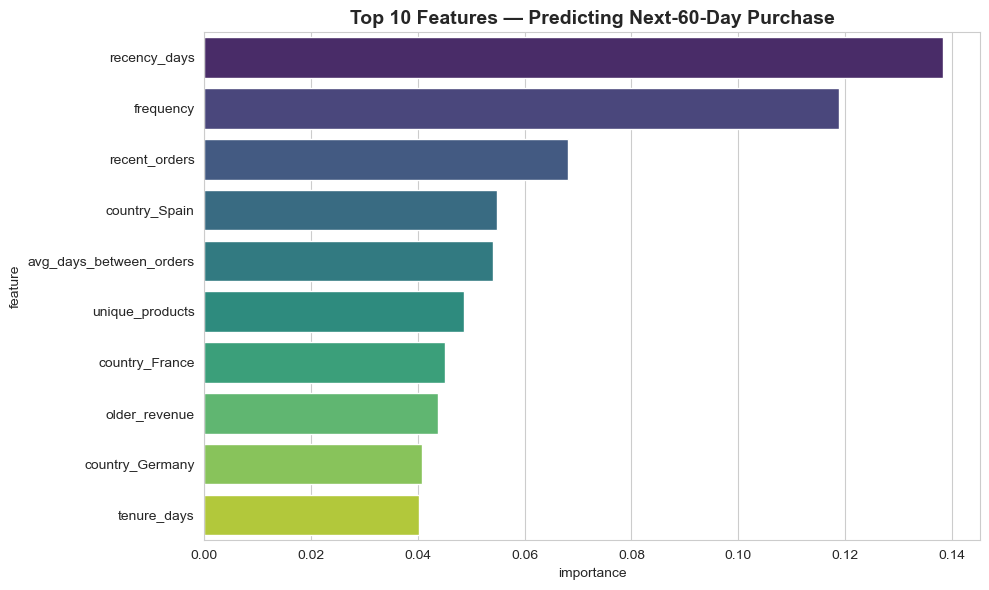

In [23]:
# One-hot encode country
top_countries = features_v3['country'].value_counts().head(5).index.tolist()
features_v3['country_grouped'] = features_v3['country'].where(
    features_v3['country'].isin(top_countries),
    'Other'
)
features_v3_enc = pd.get_dummies(features_v3, columns=['country_grouped'], prefix='country')

X_v3 = features_v3_enc.drop(['Customer ID', 'country', 'will_buy'], axis=1)
y_v3 = features_v3_enc['will_buy']

X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_v3, y_v3, test_size=0.20, random_state=42, stratify=y_v3
)

# Train XGBoost
xgb_v3 = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb_v3.fit(X_train_v3, y_train_v3)

xgb_v3_probs = xgb_v3.predict_proba(X_test_v3)[:, 1]
xgb_v3_preds = xgb_v3.predict(X_test_v3)

print("=== XGBoost V3 (Predict Next-60-Day Purchase) ===")
print(f"ROC-AUC: {roc_auc_score(y_test_v3, xgb_v3_probs):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_v3, xgb_v3_preds, target_names=['Will NOT buy', 'Will buy']))

# Feature importance
fi_v3 = pd.DataFrame({
    'feature': X_train_v3.columns,
    'importance': xgb_v3.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Top 10 Features ===")
print(fi_v3.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_v3.head(10), x='importance', y='feature', palette='viridis')
plt.title('Top 10 Features — Predicting Next-60-Day Purchase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
# Score ALL customers (including training ones, for full population view)
all_features = features_v3_enc.drop(['Customer ID', 'country', 'will_buy'], axis=1)
all_probs = xgb_v3.predict_proba(all_features)[:, 1]

# Build the final business output
predictions_df = features_v3[['Customer ID', 'country', 'frequency', 'monetary', 'recency_days']].copy()
predictions_df['churn_probability'] = 1 - all_probs  # probability of NOT buying
predictions_df['will_buy_probability'] = all_probs
predictions_df['actual_outcome'] = features_v3['will_buy'].map({0: 'Did Not Buy', 1: 'Bought'})

# Risk tiers
predictions_df['risk_tier'] = pd.cut(
    predictions_df['churn_probability'],
    bins=[0, 0.25, 0.5, 0.75, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk']
)

print(f"Total customers scored: {len(predictions_df):,}")
print(f"\nDistribution by risk tier:")
print(predictions_df['risk_tier'].value_counts().sort_index())

predictions_df.head()

Total customers scored: 5,492

Distribution by risk tier:
risk_tier
Low Risk          960
Medium Risk       720
High Risk        1202
Critical Risk    2610
Name: count, dtype: int64


,Customer ID,country,frequency,monetary,recency_days,churn_probability,will_buy_probability,actual_outcome,risk_tier
0,12346,United Kingdom,3,77352.96,265,0.929363,0.070637,Did Not Buy,Critical Risk
1,12347,Iceland,6,3402.39,69,0.191805,0.808195,Bought,Low Risk
2,12348,Finland,5,1658.40,14,0.921193,0.078807,Did Not Buy,Critical Risk
3,12349,Italy,2,2221.14,347,0.375449,0.624551,Bought,Medium Risk
4,12350,Norway,1,294.40,249,0.946415,0.053585,Did Not Buy,Critical Risk


In [25]:
# Calculate revenue at risk by tier
risk_summary = predictions_df.groupby('risk_tier').agg(
    customers=('Customer ID', 'count'),
    total_revenue=('monetary', 'sum'),
    avg_revenue=('monetary', 'mean'),
    avg_churn_prob=('churn_probability', 'mean')
).round(2)

risk_summary['pct_of_customers'] = (risk_summary['customers'] / risk_summary['customers'].sum() * 100).round(1)
risk_summary['pct_of_revenue'] = (risk_summary['total_revenue'] / risk_summary['total_revenue'].sum() * 100).round(1)

print("=== REVENUE AT RISK ===\n")
print(risk_summary)

# Critical insight: top 100 highest-risk customers
top_100_risk = predictions_df.sort_values('churn_probability', ascending=False).head(100)
print(f"\n=== TOP 100 AT-RISK CUSTOMERS ===")
print(f"Combined historical revenue: £{top_100_risk['monetary'].sum():,.0f}")
print(f"Average churn probability: {top_100_risk['churn_probability'].mean()*100:.1f}%")
print(f"Average historical spend: £{top_100_risk['monetary'].mean():,.0f}")

=== REVENUE AT RISK ===

               customers  total_revenue  avg_revenue  avg_churn_prob  \
risk_tier                                                              
Low Risk             960     9030101.17      9406.36            0.11   
Medium Risk          720     1372307.85      1905.98            0.38   
High Risk           1202     1589231.88      1322.16            0.64   
Critical Risk       2610     2749130.83      1053.31            0.88   

               pct_of_customers  pct_of_revenue  
risk_tier                                        
Low Risk                   17.5            61.3  
Medium Risk                13.1             9.3  
High Risk                  21.9            10.8  
Critical Risk              47.5            18.6  

=== TOP 100 AT-RISK CUSTOMERS ===
Combined historical revenue: £49,472
Average churn probability: 98.9%
Average historical spend: £495


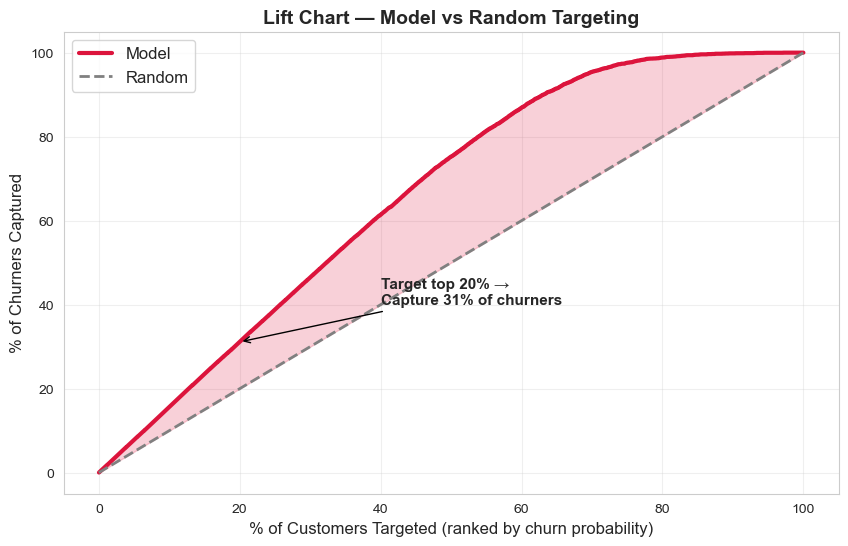


💡 Business insight: Targeting top 20% of customers by churn risk captures 31% of all churners
This is a 1.6x lift over random targeting


In [26]:
# Sort by churn probability descending and calculate cumulative captures
sorted_df = predictions_df.sort_values('churn_probability', ascending=False).reset_index(drop=True)
sorted_df['rank'] = range(1, len(sorted_df) + 1)
sorted_df['rank_pct'] = sorted_df['rank'] / len(sorted_df) * 100

# What % of actual churners do we capture if we target top N%?
actual_churners = sorted_df['actual_outcome'] == 'Did Not Buy'
sorted_df['cum_churners_captured'] = actual_churners.cumsum()
sorted_df['cum_churn_pct'] = sorted_df['cum_churners_captured'] / actual_churners.sum() * 100

# Plot lift curve
plt.figure(figsize=(10, 6))
plt.plot(sorted_df['rank_pct'], sorted_df['cum_churn_pct'], 
         label='Model', linewidth=3, color='crimson')
plt.plot([0, 100], [0, 100], '--', label='Random', color='gray', linewidth=2)
plt.fill_between(sorted_df['rank_pct'], sorted_df['cum_churn_pct'], 
                  sorted_df['rank_pct'], alpha=0.2, color='crimson')

plt.xlabel('% of Customers Targeted (ranked by churn probability)', fontsize=12)
plt.ylabel('% of Churners Captured', fontsize=12)
plt.title('Lift Chart — Model vs Random Targeting', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Annotation at top 20%
target_pct = 20
captured = sorted_df[sorted_df['rank_pct'] <= target_pct]['cum_churn_pct'].iloc[-1]
plt.annotate(
    f'Target top {target_pct}% →\nCapture {captured:.0f}% of churners',
    xy=(target_pct, captured), xytext=(40, 40),
    fontsize=11, fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='black')
)
plt.show()

print(f"\n💡 Business insight: Targeting top 20% of customers by churn risk captures {captured:.0f}% of all churners")
print(f"This is a {captured/20:.1f}x lift over random targeting")

In [27]:
# Export the scored customer file for Power BI dashboard
predictions_df.to_csv(
    r"C:\Users\jumma\Downloads\churn_predictions.csv", 
    index=False
)
predictions_df.to_parquet(
    r"C:\Users\jumma\Downloads\churn_predictions.parquet"
)

print(f"✓ Saved {len(predictions_df):,} customer predictions")
print(f"✓ Ready for Power BI integration")
print(f"\nColumns:")
print(predictions_df.columns.tolist())

✓ Saved 5,492 customer predictions
✓ Ready for Power BI integration

Columns:
['Customer ID', 'country', 'frequency', 'monetary', 'recency_days', 'churn_probability', 'will_buy_probability', 'actual_outcome', 'risk_tier']


In [28]:
# THE ACTIONABLE LIST: high-value AND at-risk
high_value_at_risk = predictions_df[
    (predictions_df['risk_tier'].isin(['High Risk', 'Critical Risk'])) &
    (predictions_df['monetary'] >= 1000)  # only customers with £1k+ historical spend
].sort_values('monetary', ascending=False).head(100)

print("=== HIGH-VALUE AT-RISK CUSTOMERS (Top 100) ===\n")
print(f"Customers: {len(high_value_at_risk)}")
print(f"Combined historical revenue: £{high_value_at_risk['monetary'].sum():,.0f}")
print(f"Average historical spend: £{high_value_at_risk['monetary'].mean():,.0f}")
print(f"Average churn probability: {high_value_at_risk['churn_probability'].mean()*100:.1f}%")
print(f"\nCountries represented:")
print(high_value_at_risk['country'].value_counts().head())

# Save this as the primary business deliverable
high_value_at_risk.to_csv(
    r"C:\Users\jumma\Downloads\high_value_at_risk_customers.csv", 
    index=False
)
print("\n✓ Saved high-value at-risk list for business action")

# Show the top 10
print("\n=== TOP 10 HIGH-VALUE AT-RISK ACCOUNTS ===")
print(high_value_at_risk[['Customer ID', 'country', 'monetary', 'frequency', 'recency_days', 'churn_probability', 'risk_tier']].head(10))

=== HIGH-VALUE AT-RISK CUSTOMERS (Top 100) ===

Customers: 100
Combined historical revenue: £1,264,274
Average historical spend: £12,643
Average churn probability: 79.5%

Countries represented:
country
United Kingdom    87
Denmark            2
Germany            2
France             2
Sweden             1
Name: count, dtype: int64

✓ Saved high-value at-risk list for business action

=== TOP 10 HIGH-VALUE AT-RISK ACCOUNTS ===
      Customer ID         country  monetary  frequency  recency_days  \
0           12346  United Kingdom  77352.96          3           265   
4078        16754  United Kingdom  65500.07         29           311   
679         13093  United Kingdom  54144.25         55           215   
5088        17850  United Kingdom  51208.87        155           311   
3138        15749  United Kingdom  44534.30          3           174   
2536        15098  United Kingdom  39916.50          3           121   
1430        13902         Denmark  34023.26          5           5

In [29]:
# Revenue protection opportunity
total_at_risk_value = high_value_at_risk['monetary'].sum()
typical_retention_rate = 0.30  # industry average for re-engagement campaigns

protected_revenue = total_at_risk_value * typical_retention_rate

print("=== BUSINESS CASE ===\n")
print(f"Total at-risk revenue (top 100 high-value accounts): £{total_at_risk_value:,.0f}")
print(f"Assumed retention success rate (industry avg): {typical_retention_rate*100:.0f}%")
print(f"Expected protected revenue: £{protected_revenue:,.0f}")
print(f"\nCompared to acquiring new customers:")
print(f"Cost to acquire ~{int(typical_retention_rate*100)} new customers worth £{total_at_risk_value/100:,.0f}/each = significantly higher")
print(f"\n💡 Conclusion: Retention campaign on these 100 accounts could protect")
print(f"   ~£{protected_revenue:,.0f} in annual revenue at much lower cost than acquisition.")

=== BUSINESS CASE ===

Total at-risk revenue (top 100 high-value accounts): £1,264,274
Assumed retention success rate (industry avg): 30%
Expected protected revenue: £379,282

Compared to acquiring new customers:
Cost to acquire ~30 new customers worth £12,643/each = significantly higher

💡 Conclusion: Retention campaign on these 100 accounts could protect
   ~£379,282 in annual revenue at much lower cost than acquisition.


In [30]:
# Categorise WHY each customer is at risk
def diagnose_risk(row):
    reasons = []
    if row['recency_days'] > 180:
        reasons.append("Long inactivity (>6 months)")
    if row['recency_days'] > 90 and row['recency_days'] <= 180:
        reasons.append("Moderate inactivity (3-6 months)")
    if row['frequency'] <= 3:
        reasons.append("Low order count")
    if row['frequency'] >= 30 and row['recency_days'] > 60:
        reasons.append("Active buyer who stopped")
    if row['monetary'] >= 50000:
        reasons.append("VIP account - escalate")
    if row['monetary'] >= 10000 and row['monetary'] < 50000:
        reasons.append("Major account")
    return " | ".join(reasons) if reasons else "Standard risk profile"

# Apply to top 100 high-value at-risk
high_value_at_risk['risk_reasons'] = high_value_at_risk.apply(diagnose_risk, axis=1)

# Show top 10 with reasons
print("=== TOP 10 AT-RISK ACCOUNTS WITH DIAGNOSIS ===\n")
print(high_value_at_risk[['Customer ID', 'country', 'monetary', 'churn_probability', 'risk_reasons']].head(10).to_string(index=False))

# Save updated file
high_value_at_risk.to_csv(
    r"C:\Users\jumma\Downloads\high_value_at_risk_customers.csv", 
    index=False
)
print("\n✓ Updated CSV with risk reasons")

=== TOP 10 AT-RISK ACCOUNTS WITH DIAGNOSIS ===

 Customer ID        country  monetary  churn_probability                                                                    risk_reasons
       12346 United Kingdom  77352.96           0.929363          Long inactivity (>6 months) | Low order count | VIP account - escalate
       16754 United Kingdom  65500.07           0.917082                            Long inactivity (>6 months) | VIP account - escalate
       13093 United Kingdom  54144.25           0.903756 Long inactivity (>6 months) | Active buyer who stopped | VIP account - escalate
       17850 United Kingdom  51208.87           0.937120 Long inactivity (>6 months) | Active buyer who stopped | VIP account - escalate
       15749 United Kingdom  44534.30           0.959763              Moderate inactivity (3-6 months) | Low order count | Major account
       15098 United Kingdom  39916.50           0.901695              Moderate inactivity (3-6 months) | Low order count | Major a